In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, random_split
from tqdm.notebook import tqdm

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

full_train_dataset = torchvision.datasets.EMNIST(
    root='./data', split='balanced', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.EMNIST(
    root='./data', split='balanced', train=False, download=True, transform=transform
)

val_size = int(0.2 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=generator)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [5]:
class MLP(nn.Module):
    def __init__(self, input_size, num_classes, hidden_sizes, dropout=0.0, use_batchnorm=False):
        super().__init__()
        layers = []
        current_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(current_size, hidden_size))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            current_size = hidden_size
            
        layers.append(nn.Linear(current_size, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

In [6]:
def calculate_accuracy(y_pred, y_true):
    preds = torch.argmax(y_pred, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion, device, clip_value=None):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        
        if clip_value is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
            
        optimizer.step()
        
        total_loss += loss.item() * images.size(0)
        total_acc += calculate_accuracy(outputs, labels) * images.size(0)
        
    return total_loss / len(loader.dataset), total_acc / len(loader.dataset)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            total_acc += calculate_accuracy(outputs, labels) * images.size(0)
            
    return total_loss / len(loader.dataset), total_acc / len(loader.dataset)

def execute_training(model, train_loader, val_loader, optimizer, scheduler, criterion, device, epochs, patience=None, clip_value=None):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_weights = None
    stagnation_counter = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, clip_value)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        if scheduler:
            scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch:2d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        if patience:
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                stagnation_counter = 0
            else:
                stagnation_counter += 1
                if stagnation_counter >= patience:
                    break

    if patience and best_weights:
        model.load_state_dict(best_weights)
        return history, best_val_acc
    
    return history, history['val_acc'][-1]

In [7]:
def run_experiment(exp_id, desc, config, train_loader, val_loader, device):
    print(f"\nRunning {exp_id}: {desc}")
    
    model = MLP(
        input_size=28*28, 
        num_classes=47,
        hidden_sizes=config['hidden_sizes'],
        dropout=config['dropout'],
        use_batchnorm=config['use_batchnorm']
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    
    if config['optimizer'] == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    else:
        optimizer = optim.SGD(model.parameters(), lr=config['lr'], momentum=config['momentum'], weight_decay=config['weight_decay'])
        
    scheduler = None
    if config['use_scheduler']:
        scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
        
    history, best_val_acc = execute_training(
        model, train_loader, val_loader, optimizer, scheduler, criterion, device,
        epochs=config['epochs'],
        patience=config['patience'],
        clip_value=config.get('clip_value')
    )
    
    result_record = {
        'experiment_id': exp_id,
        'model_summary': desc,
        'optimizer': config['optimizer'],
        'lr': config['lr'],
        'momentum': config['momentum'],
        'weight_decay': config['weight_decay'],
        'clip_value': config.get('clip_value', None),
        'epochs_trained': len(history['train_loss']),
        'best_val_accuracy': best_val_acc,
        'best_val_loss': min(history['val_loss'])
    }
    
    return model, history, result_record

In [8]:
base_config = {
    'hidden_sizes': [512, 256],
    'dropout': 0.0,
    'use_batchnorm': False,
    'optimizer': 'Adam',
    'lr': 1e-3,
    'momentum': 0.0,
    'weight_decay': 0.0,
    'epochs': 20,
    'patience': None,
    'use_scheduler': False,
    'clip_value': None
}

experiments_plan = [
    ('E1', 'Base MLP (no dropout, no batchnorm)', {}),
    ('E2', 'Dropout p=0.3', {'dropout': 0.3}),
    ('E3', 'BatchNorm', {'use_batchnorm': True}),
    ('E4', 'EarlyStopping + Best of E2/E3 + Gradient Clipping', {'dropout': 0.3, 'patience': 5, 'use_scheduler': True, 'clip_value': 1.0}),
    ('O1', 'Adam, lr=1e-1', {'dropout': 0.3, 'lr': 1e-1, 'epochs': 8}),
    ('O2', 'Adam, lr=1e-5', {'dropout': 0.3, 'lr': 1e-5, 'epochs': 8}),
    ('O3', 'SGD, lr=1e-2, momentum=0.9', {'dropout': 0.3, 'optimizer': 'SGD', 'lr': 1e-2, 'momentum': 0.9, 'weight_decay': 1e-4, 'epochs': 10})
]

all_results = []
histories = {}
best_overall_model = None

for exp_id, desc, overrides in experiments_plan:
    current_config = base_config.copy()
    current_config.update(overrides)
    
    model, history, result = run_experiment(exp_id, desc, current_config, train_loader, val_loader, device)
    all_results.append(result)
    histories[exp_id] = history
    
    if exp_id == 'E4':
        best_overall_model = model


Running E1: Base MLP (no dropout, no batchnorm)


Training:   0%|          | 0/705 [00:00<?, ?it/s]

Epoch  1 | Train Loss: 1.0925 | Train Acc: 0.6794 | Val Loss: 0.6906 | Val Acc: 0.7834


Training:   0%|          | 0/705 [00:00<?, ?it/s]

Epoch  2 | Train Loss: 0.5833 | Train Acc: 0.8101 | Val Loss: 0.5485 | Val Acc: 0.8199


...

Epoch  8 | Train Loss: 0.6239 | Train Acc: 0.7985 | Val Loss: 0.5342 | Val Acc: 0.8276


Training:   0%|          | 0/705 [00:00<?, ?it/s]

Epoch  9 | Train Loss: 0.5991 | Train Acc: 0.8043 | Val Loss: 0.5206 | Val Acc: 0.8305


Training:   0%|          | 0/705 [00:00<?, ?it/s]

Epoch 10 | Train Loss: 0.5768 | Train Acc: 0.8108 | Val Loss: 0.5005 | Val Acc: 0.8344


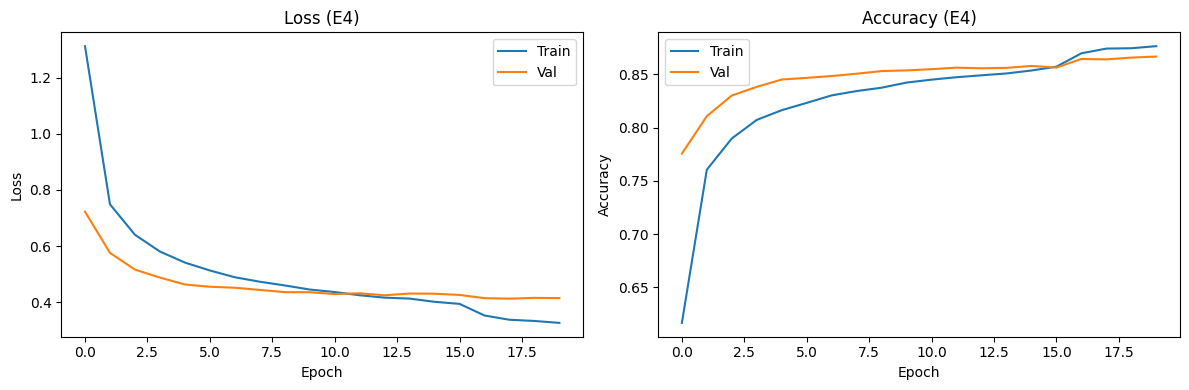

Test accuracy of best model (E4): 0.8622
Test loss: 0.4357


In [9]:
df_results = pd.DataFrame(all_results)
df_results.insert(0, 'dataset', 'EMNIST')
df_results.insert(1, 'seed', 42)

Path("artifacts/figures").mkdir(parents=True, exist_ok=True)
df_results.to_csv('artifacts/runs.csv', index=False)
torch.save(best_overall_model.state_dict(), 'artifacts/best_model.pt')

best_config_out = base_config.copy()
best_config_out.update(experiments_plan[3][2])
with open('artifacts/best_config.json', 'w') as f:
    json.dump(best_config_out, f, indent=4)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(histories['E4']['train_loss'], label='Train')
plt.plot(histories['E4']['val_loss'], label='Val')
plt.title('Loss (E4)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(histories['E4']['train_acc'], label='Train')
plt.plot(histories['E4']['val_acc'], label='Val')
plt.title('Accuracy (E4)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('artifacts/figures/curves_best.png', dpi=150)
plt.show()

test_loss, test_acc = evaluate(best_overall_model, test_loader, nn.CrossEntropyLoss(), device)
print(f"Test accuracy of best model (E4): {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")